# EDA Notebook — Multimodal Dataset (Text + Image)

This notebook computes the required EDA:
- Class distribution **before/after filtering** (with histogram)
- Missing fields (empty title/description/URL)
- Text length statistics (characters and optional tokens)
- Image resolution distribution + detection of unusually small/invalid images

✅ Edit only the **CONFIG** cell first.


In [ ]:
# =====================
# CONFIG (EDIT ME)
# =====================
CSV_PATH = "/Users/prashantkhanal/Desktop/deep learning/coursework/productclassification/project_root/data/processed_labels.csv"   # <-- path to your CSV
IMAGE_ROOT = ""                      # <-- optional prefix folder if image_path is relative (e.g., "data/")
OUT_DIR = "eda_outputs"              # <-- outputs (plots + summary)

# Column candidates (the notebook will auto-detect if your names differ)
CANDIDATE_COLS = {
    "label": ["label", "class", "category", "target", "y"],
    "title": ["title", "product_title", "headline", "name"],
    "description": ["description", "desc", "text", "review", "body"],
    "url": ["url", "image_url", "link", "product_url"],
    "image_path": ["image_path", "path", "img_path", "image", "filepath"],
    "split": ["split", "set", "partition"]
}

# Filtering rules (used to compute "after filtering")
MIN_TEXT_CHARS = 1          # treat empty/near-empty as missing
MIN_IMG_WIDTH = 50          # unusually small image threshold
MIN_IMG_HEIGHT = 50         # unusually small image threshold

# Optional tokenization for text length statistics (requires transformers)
USE_TOKEN_STATS = True
TOKENIZER_NAME = "openai/clip-vit-base-patch32"  # or "roberta-base", etc.


In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

os.makedirs(OUT_DIR, exist_ok=True)

def pick_col(df, candidates):
    """Pick the first column in df matching any of candidates."""
    for c in candidates:
        if c in df.columns:
            return c
    # case-insensitive match
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, float) and np.isnan(x):
        return True
    s = str(x).strip()
    return len(s) == 0

def safe_join(root, path):
    if path is None:
        return None
    p = str(path)
    if IMAGE_ROOT and not os.path.isabs(p):
        return os.path.join(IMAGE_ROOT, p)
    return p


In [3]:
# Load dataset
df = pd.read_csv(CSV_PATH)
print("Loaded:", df.shape)
display(df.head(3))

# Auto-detect columns
col_label = pick_col(df, CANDIDATE_COLS["label"])
col_title = pick_col(df, CANDIDATE_COLS["title"])
col_desc  = pick_col(df, CANDIDATE_COLS["description"])
col_url   = pick_col(df, CANDIDATE_COLS["url"])
col_img   = pick_col(df, CANDIDATE_COLS["image_path"])
col_split = pick_col(df, CANDIDATE_COLS["split"])

print("Detected columns:")
print(" label:", col_label)
print(" title:", col_title)
print(" description:", col_desc)
print(" url:", col_url)
print(" image_path:", col_img)
print(" split:", col_split)

assert col_label is not None, "Could not detect label/class column. Update CANDIDATE_COLS['label']."
assert col_img is not None, "Could not detect image_path column. Update CANDIDATE_COLS['image_path']."

# Compose text field (title + description if both exist)
if col_title and col_desc:
    df["_text"] = df[col_title].fillna("").astype(str).str.strip() + " " + df[col_desc].fillna("").astype(str).str.strip()
elif col_desc:
    df["_text"] = df[col_desc].fillna("").astype(str).str.strip()
elif col_title:
    df["_text"] = df[col_title].fillna("").astype(str).str.strip()
else:
    df["_text"] = ""


Loaded: (1860, 6)


,uniq_id,image_path,text,label,category_name,split
0,1682e3640f01415595ebdd8ab3475100,data/images/1682e3640f01415595ebdd8ab3475100.jpg,"Terra by Battat – 4 Dinosaur Toys, Medium – Di...",4,NaN,val
1,83fb575180c741d78f1f2adf549c2b8f,data/images/83fb575180c741d78f1f2adf549c2b8f.jpg,Pokemon TCG: Sun and Moon Crimson Invasion Eli...,4,NaN,train
2,1aaa8a2f3e3446a0aaf0e5f9fae4a148,data/images/1aaa8a2f3e3446a0aaf0e5f9fae4a148.jpg,Funko Pop! Games: Persona 5 - The Joker (Style...,4,NaN,train


Detected columns:
 label: label
 title: None
 description: text
 url: None
 image_path: image_path
 split: split


## 1) Class distribution before/after filtering

,count_before
label,
0,274
1,274
2,252
3,235
4,825


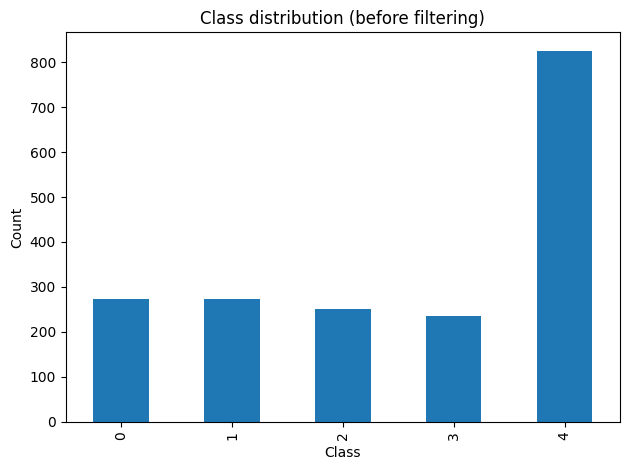

,count_after
label,
0,274
1,274
2,252
3,235
4,825


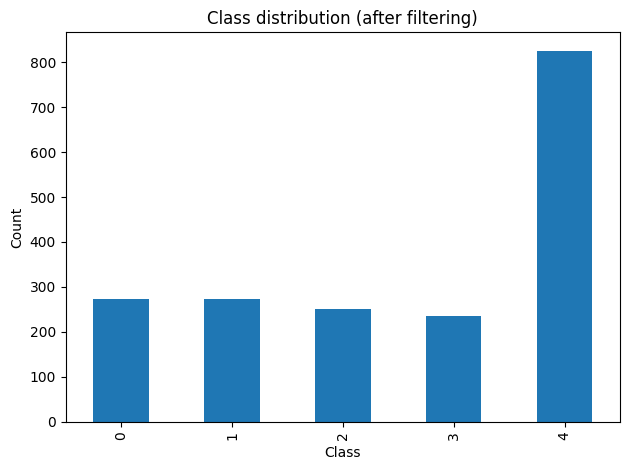

Dropped samples: 0  / Remaining: 1860


In [4]:
# BEFORE filtering
counts_before = df[col_label].value_counts().sort_index()
display(counts_before.to_frame("count_before"))

plt.figure()
counts_before.plot(kind="bar")
plt.title("Class distribution (before filtering)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "class_hist_before.png"), dpi=200)
plt.show()

# Define filtering masks
mask_missing_title = df[col_title].apply(is_empty) if col_title else pd.Series([False]*len(df))
mask_missing_desc  = df[col_desc].apply(is_empty)  if col_desc  else pd.Series([False]*len(df))
mask_missing_url   = df[col_url].apply(is_empty)   if col_url   else pd.Series([False]*len(df))

mask_missing_text  = df["_text"].fillna("").astype(str).str.strip().str.len() < MIN_TEXT_CHARS
mask_missing_img   = df[col_img].apply(is_empty)

# "After filtering" = remove missing text or missing image path or missing URL (if URL column exists)
mask_drop = mask_missing_img | mask_missing_text
if col_url:
    mask_drop = mask_drop | mask_missing_url

df_filt = df[~mask_drop].copy()

counts_after = df_filt[col_label].value_counts().sort_index()
display(counts_after.to_frame("count_after"))

plt.figure()
counts_after.plot(kind="bar")
plt.title("Class distribution (after filtering)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "class_hist_after.png"), dpi=200)
plt.show()

print("Dropped samples:", int(mask_drop.sum()), " / Remaining:", df_filt.shape[0])


## 2) Missing fields (empty title / description / URL)

In [5]:
missing_summary = {}
missing_summary["empty_title"] = int(df[col_title].apply(is_empty).sum()) if col_title else None
missing_summary["empty_description"] = int(df[col_desc].apply(is_empty).sum()) if col_desc else None
missing_summary["empty_url"] = int(df[col_url].apply(is_empty).sum()) if col_url else None
missing_summary["empty_or_short_text"] = int(mask_missing_text.sum())
missing_summary["empty_image_path"] = int(mask_missing_img.sum())
missing_summary["dropped_total_by_rules"] = int(mask_drop.sum())

display(pd.DataFrame([missing_summary]).T.rename(columns={0:"count"}))


,count
empty_title,None
empty_description,0
empty_url,None
empty_or_short_text,0
empty_image_path,0
dropped_total_by_rules,0


## 3) Text length statistics (characters + optional tokens)

,n,min,max,mean,median,p95
chars,1860,1,200,64.124731,58.0,127.1


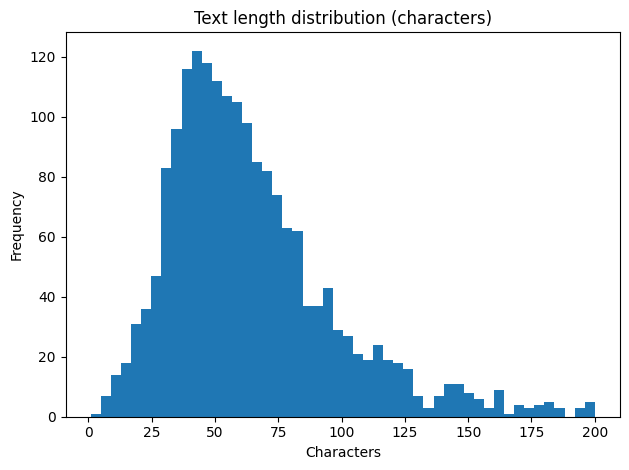

/Users/prashantkhanal/Desktop/deep learning/coursework/productclassification/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /openai/clip-vit-base-patch32/resolve/main/tokenizer_config.json (Caused by ConnectTimeoutError(<HTTPSConnection(host='huggingface.co', port=443) at 0x123ec3e00>, 'Connection to huggingface.co timed out. (connect timeout=10)'))"), '(Request ID: 4ebc2a5c-07aa-43d3-841e-1a26bf790100)')' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /openai/clip-vit-base-patch32/resolve/main/tokeni

,n,min,max,mean,median,p95
tokens,1860,3,57,16.936022,15.0,34.0


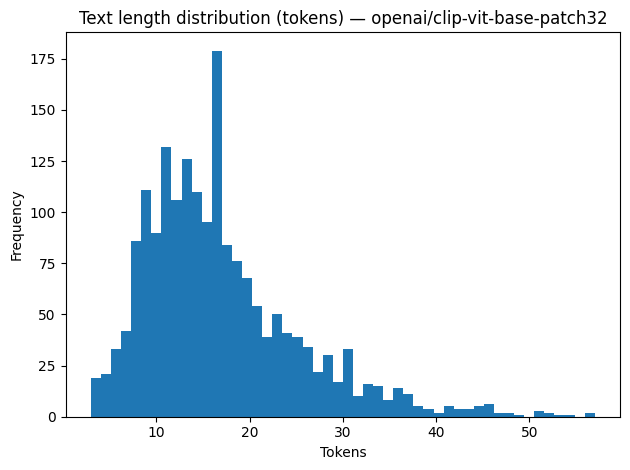

In [6]:
text_series = df_filt["_text"].fillna("").astype(str)

char_lens = text_series.str.len().astype(int)
stats_chars = {
    "n": int(len(char_lens)),
    "min": int(char_lens.min()) if len(char_lens) else 0,
    "max": int(char_lens.max()) if len(char_lens) else 0,
    "mean": float(char_lens.mean()) if len(char_lens) else 0.0,
    "median": float(char_lens.median()) if len(char_lens) else 0.0,
    "p95": float(char_lens.quantile(0.95)) if len(char_lens) else 0.0,
}
display(pd.DataFrame([stats_chars], index=["chars"]))

plt.figure()
plt.hist(char_lens, bins=50)
plt.title("Text length distribution (characters)")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "text_len_chars_hist.png"), dpi=200)
plt.show()

token_stats = None
if USE_TOKEN_STATS:
    try:
        from transformers import AutoTokenizer
        tok = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
        token_lens = text_series.apply(lambda s: len(tok.encode(s, add_special_tokens=True))).astype(int)

        token_stats = {
            "n": int(len(token_lens)),
            "min": int(token_lens.min()) if len(token_lens) else 0,
            "max": int(token_lens.max()) if len(token_lens) else 0,
            "mean": float(token_lens.mean()) if len(token_lens) else 0.0,
            "median": float(token_lens.median()) if len(token_lens) else 0.0,
            "p95": float(token_lens.quantile(0.95)) if len(token_lens) else 0.0,
        }
        display(pd.DataFrame([token_stats], index=["tokens"]))

        plt.figure()
        plt.hist(token_lens, bins=50)
        plt.title(f"Text length distribution (tokens) — {TOKENIZER_NAME}")
        plt.xlabel("Tokens")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "text_len_tokens_hist.png"), dpi=200)
        plt.show()
    except Exception as e:
        print("Token stats skipped:", repr(e))


## 4) Image resolution distribution (detect small/invalid images)

In [ ]:
paths = df_filt[col_img].apply(lambda p: safe_join(IMAGE_ROOT, p)).tolist()
df[col_img] = df[col_img].astype(str).str.replace("\\", "/", regex=False)

widths, heights = [], []
invalid = 0
missing_file = 0

for p in paths:
    if p is None or str(p).strip() == "":
        invalid += 1
        continue
    if not os.path.exists(p):
        missing_file += 1
        continue
    try:
        with Image.open(p) as im:
            w, h = im.size
            widths.append(w)
            heights.append(h)
    except (UnidentifiedImageError, OSError):
        invalid += 1

widths = np.array(widths, dtype=int)
heights = np.array(heights, dtype=int)

print("Images analysed:", len(widths))
print("Missing files:", missing_file)
print("Unreadable/corrupt:", invalid)

if len(widths) > 0:
    plt.figure()
    plt.scatter(widths, heights, s=8)
    plt.title("Image resolution scatter (W vs H)")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "img_resolution_scatter.png"), dpi=200)
    plt.show()

    plt.figure()
    plt.hist(widths, bins=50)
    plt.title("Image width distribution")
    plt.xlabel("Width (px)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "img_width_hist.png"), dpi=200)
    plt.show()

    plt.figure()
    plt.hist(heights, bins=50)
    plt.title("Image height distribution")
    plt.xlabel("Height (px)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "img_height_hist.png"), dpi=200)
    plt.show()

    small_count = int(((widths < MIN_IMG_WIDTH) | (heights < MIN_IMG_HEIGHT)).sum())
    print(f"Unusually small images (<{MIN_IMG_WIDTH}x<{MIN_IMG_HEIGHT}):", small_count)

    img_stats = {
        "n_readable": int(len(widths)),
        "min_w": int(widths.min()),
        "max_w": int(widths.max()),
        "mean_w": float(widths.mean()),
        "min_h": int(heights.min()),
        "max_h": int(heights.max()),
        "mean_h": float(heights.mean()),
        "missing_files": int(missing_file),
        "unreadable": int(invalid),
        "small_images": int(small_count),
    }
    display(pd.DataFrame([img_stats]))
else:
    print("No readable images found. Check IMAGE_ROOT and the image_path column.")


Images analysed: 0
Missing files: 1860
Unreadable/corrupt: 0
No readable images found. Check IMAGE_ROOT and the image_path column.


In [11]:
df[col_img].head(10)


0    data/images/1682e3640f01415595ebdd8ab3475100.jpg
1    data/images/83fb575180c741d78f1f2adf549c2b8f.jpg
2    data/images/1aaa8a2f3e3446a0aaf0e5f9fae4a148.jpg
3    data/images/21c58793ec0a489b8323abc8e582dadb.jpg
4    data/images/d36321d71b1345b7bb778c30f1119f22.jpg
5    data/images/b41a2d6ca85643c284a2b907fc1d4a05.jpg
6    data/images/20a1bb1ef9ba4005a3c729f7f32a59f5.jpg
7    data/images/ebd087cd9633495f9fa272b5fd64addc.jpg
8    data/images/87c187b9efc9427fba78a15de1db3320.jpg
9    data/images/ee6dcbc5c147409da941b3c2020fa545.jpg
Name: image_path, dtype: object

In [12]:
p = safe_join(IMAGE_ROOT, df[col_img].iloc[0])
print("Resolved path:", p)
print("Exists:", os.path.exists(p))


Resolved path: /Users/prashantkhanal/Desktop/deep learning/coursework/productclassification/project_root/data/images/data/images/1682e3640f01415595ebdd8ab3475100.jpg
Exists: False


## 5) Export a compact EDA summary (numbers to paste into report)

In [10]:
summary = {
    "rows_before": int(df.shape[0]),
    "rows_after": int(df_filt.shape[0]),
    "dropped": int(mask_drop.sum()),
    "class_counts_before": counts_before.to_dict(),
    "class_counts_after": counts_after.to_dict(),
    "missing_fields": missing_summary,
    "text_chars_stats": stats_chars,
    "text_token_stats": token_stats,
}

if 'img_stats' in globals():
    summary["image_stats"] = img_stats

summary_path = os.path.join(OUT_DIR, "eda_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved summary:", summary_path)
print("Saved plots in:", OUT_DIR)
summary


Saved summary: eda_outputs/eda_summary.json
Saved plots in: eda_outputs


{'rows_before': 1860,
 'rows_after': 1860,
 'dropped': 0,
 'class_counts_before': {0: 274, 1: 274, 2: 252, 3: 235, 4: 825},
 'class_counts_after': {0: 274, 1: 274, 2: 252, 3: 235, 4: 825},
 'missing_fields': {'empty_title': None,
  'empty_description': 0,
  'empty_url': None,
  'empty_or_short_text': 0,
  'empty_image_path': 0,
  'dropped_total_by_rules': 0},
 'text_chars_stats': {'n': 1860,
  'min': 1,
  'max': 200,
  'mean': 64.1247311827957,
  'median': 58.0,
  'p95': 127.09999999999991},
 'text_token_stats': {'n': 1860,
  'min': 3,
  'max': 57,
  'mean': 16.936021505376345,
  'median': 15.0,
  'p95': 34.0}}